# 03 — Exploratory Data Analysis (EDA)

## Objective
Discover patterns, relationships, and anomalies in the cleaned Telco Customer Churn dataset through visual and quantitative analysis. Every chart includes a written business insight.

**Analysis Themes:**
1. Churn Overview
2. Demographics & Churn
3. Contract & Billing Impact
4. Service Adoption & Retention
5. Tenure Analysis
6. Revenue Impact
7. Correlation Analysis
8. Multi-Factor Risk Profiling

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style configuration
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})

# Color palette
COLORS = {'No': '#2ecc71', 'Yes': '#e74c3c'}
PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# Load cleaned data
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Churn rate: {(df['Churn'] == 'Yes').mean()*100:.1f}%")

Loaded: 7,043 rows x 27 columns
Churn rate: 26.5%


## 1. Churn Overview

Understanding the baseline churn rate and its scale.

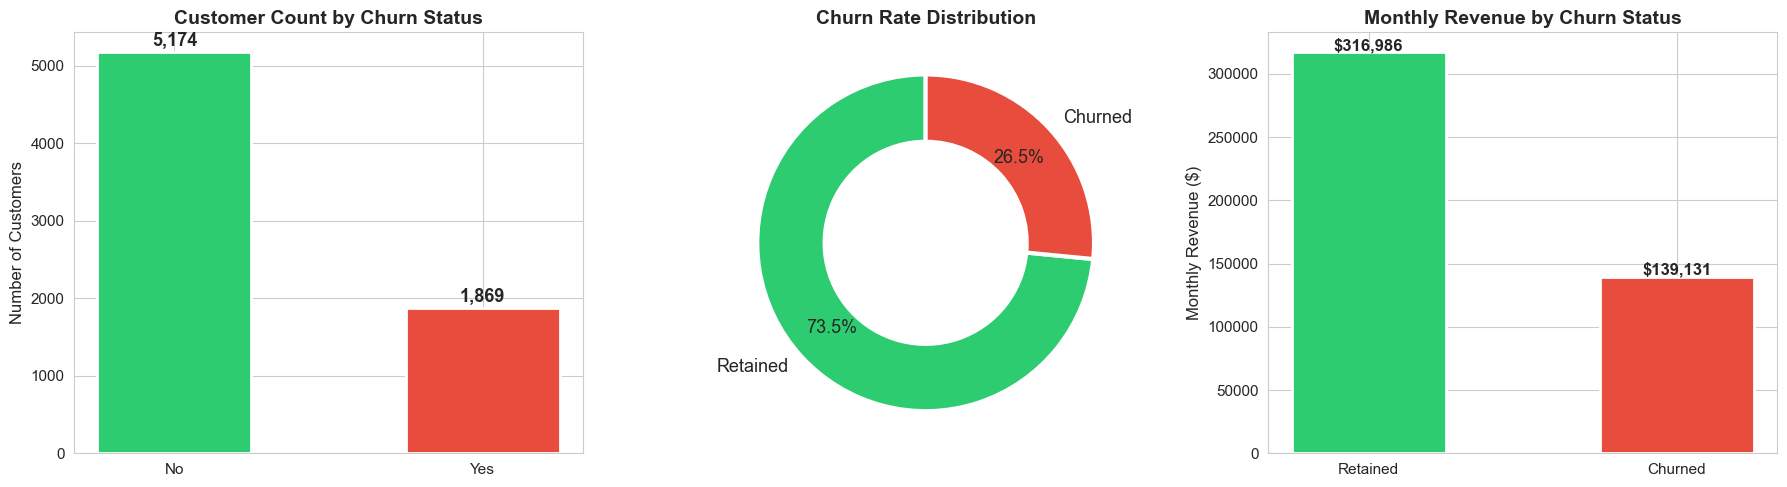

Monthly Revenue at Risk from Churned Customers: $139,131
This represents 30.5% of total monthly revenue.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a: Count
churn_counts = df['Churn'].value_counts()
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=[COLORS['No'], COLORS['Yes']], 
                   edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, 
                f'{val:,}', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Customer Count by Churn Status', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# 1b: Percentage donut
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], 
           autopct='%1.1f%%', colors=[COLORS['No'], COLORS['Yes']], startangle=90,
           textprops={'fontsize': 13}, pctdistance=0.75,
           wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'width': 0.4})
axes[1].set_title('Churn Rate Distribution', fontweight='bold')

# 1c: Revenue at risk
churned_revenue = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
retained_revenue = df[df['Churn'] == 'No']['MonthlyCharges'].sum()
rev_data = [retained_revenue, churned_revenue]
axes[2].bar(['Retained', 'Churned'], rev_data, color=[COLORS['No'], COLORS['Yes']],
           edgecolor='white', linewidth=2, width=0.5)
for i, val in enumerate(rev_data):
    axes[2].text(i, val + 2000, f'${val:,.0f}', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('Monthly Revenue by Churn Status', fontweight='bold')
axes[2].set_ylabel('Monthly Revenue ($)')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Monthly Revenue at Risk from Churned Customers: ${churned_revenue:,.0f}")
print(f"This represents {churned_revenue/(churned_revenue+retained_revenue)*100:.1f}% of total monthly revenue.")

> **Insight:** 26.5% of customers (1,869) have churned, putting approximately $\$139K$ in monthly recurring revenue at risk. While the majority of customers are retained, the churned segment contributes a disproportionately large share of revenue, suggesting many high-value customers are leaving.

## 2. Demographics & Churn

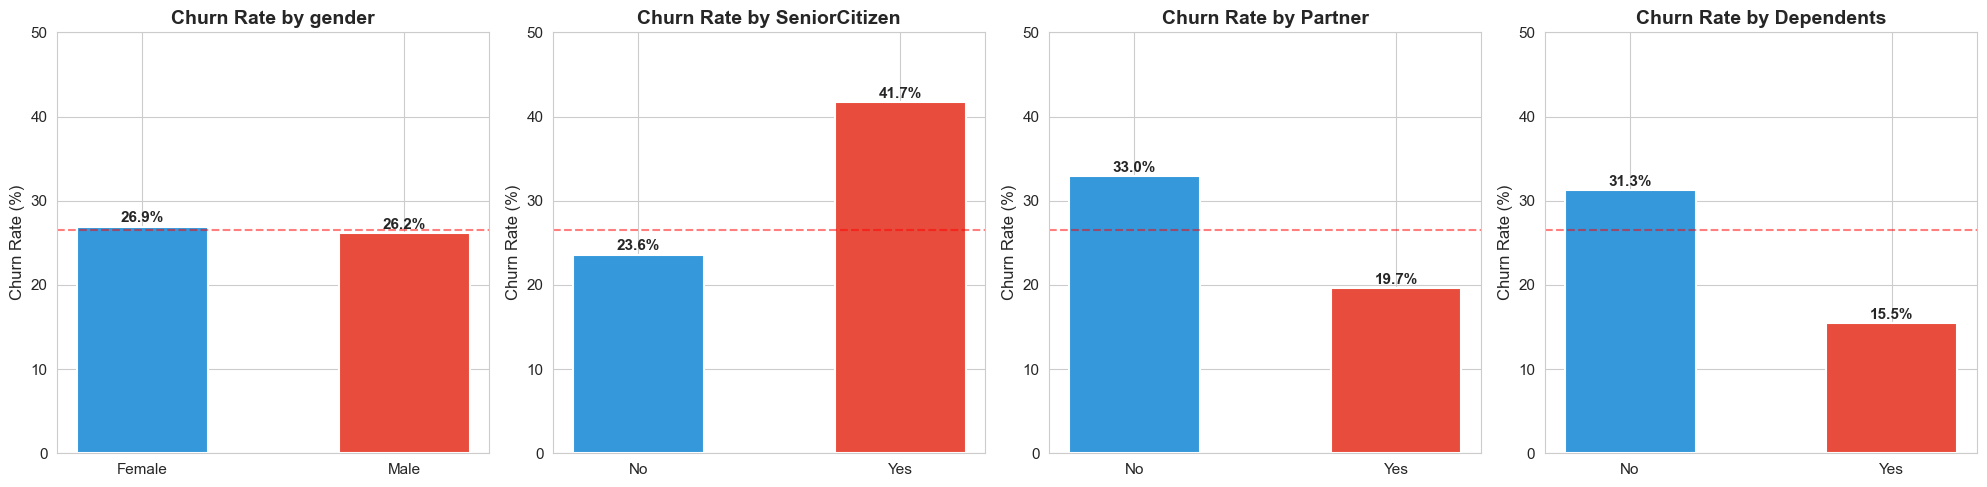

In [3]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(demo_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    bars = axes[i].bar(churn_rate.index, churn_rate.values, color=PALETTE[:len(churn_rate)],
                      edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 50)
    axes[i].axhline(y=26.5, color='red', linestyle='--', alpha=0.5, label='Overall avg')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_demographics_churn.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insights:**
> - **Gender** has virtually no impact on churn (~26-27% for both). Gender-based retention strategies are not warranted.
> - **Senior citizens** churn at a significantly higher rate (~41%) compared to non-seniors (~24%). This group needs targeted retention efforts.
> - **Customers without partners** churn more (~33%) than those with partners (~20%). Family-attached customers are stickier.
> - **Customers without dependents** churn more (~31%) than those with dependents (~15%). Household commitment strongly correlates with retention.

## 3. Contract & Billing Impact

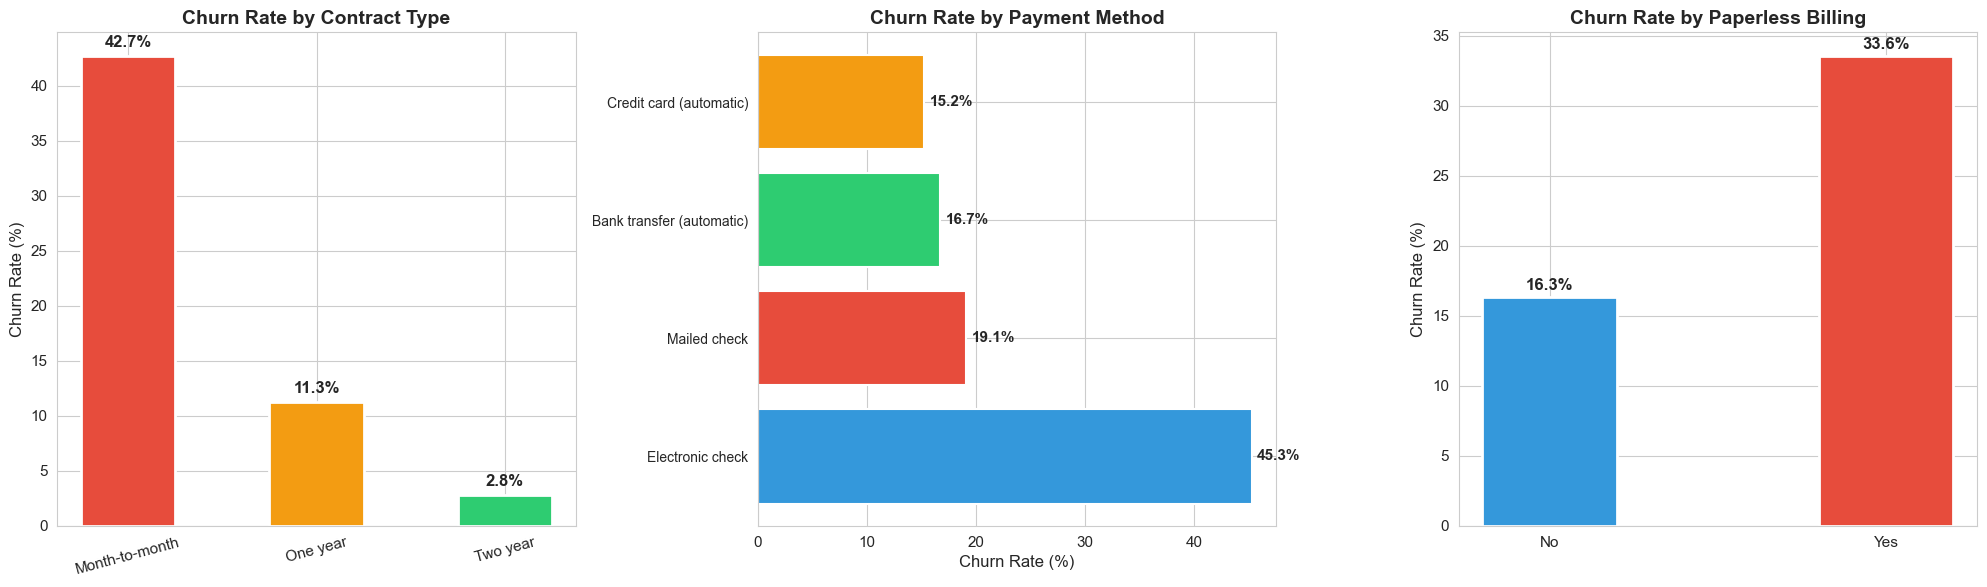

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 3a: Contract type
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_order = ['Month-to-month', 'One year', 'Two year']
contract_churn = contract_churn.reindex(contract_order)
bars = axes[0].bar(range(len(contract_churn)), contract_churn.values, 
                   color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=2, width=0.5)
axes[0].set_xticks(range(len(contract_churn)))
axes[0].set_xticklabels(contract_churn.index, rotation=15)
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')

# 3b: Payment method
pay_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
bars = axes[1].barh(range(len(pay_churn)), pay_churn.values, color=PALETTE[:4], edgecolor='white', linewidth=1.5)
axes[1].set_yticks(range(len(pay_churn)))
axes[1].set_yticklabels(pay_churn.index, fontsize=10)
for bar, val in zip(bars, pay_churn.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                va='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')

# 3c: Paperless billing
pb_churn = df.groupby('PaperlessBilling')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
bars = axes[2].bar(pb_churn.index, pb_churn.values, color=[PALETTE[0], PALETTE[1]], 
                   edgecolor='white', linewidth=2, width=0.4)
for bar, val in zip(bars, pb_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('Churn Rate by Paperless Billing', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_contract_billing_churn.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insights:**
> - **Month-to-month contracts** are the single biggest churn driver (~42% churn rate) vs ~11% for one-year and ~3% for two-year. Converting even 10% of month-to-month customers to annual contracts could significantly reduce churn.
> - **Electronic check** users churn at ~45%, far above other payment methods (~15-18%). This payment method signals disengagement — customers haven't set up automatic payments.
> - **Paperless billing** customers churn more (~34%) than paper billing (~16%). This may correlate with tech-savvy customers who are more willing to switch providers.

## 4. Service Adoption & Retention

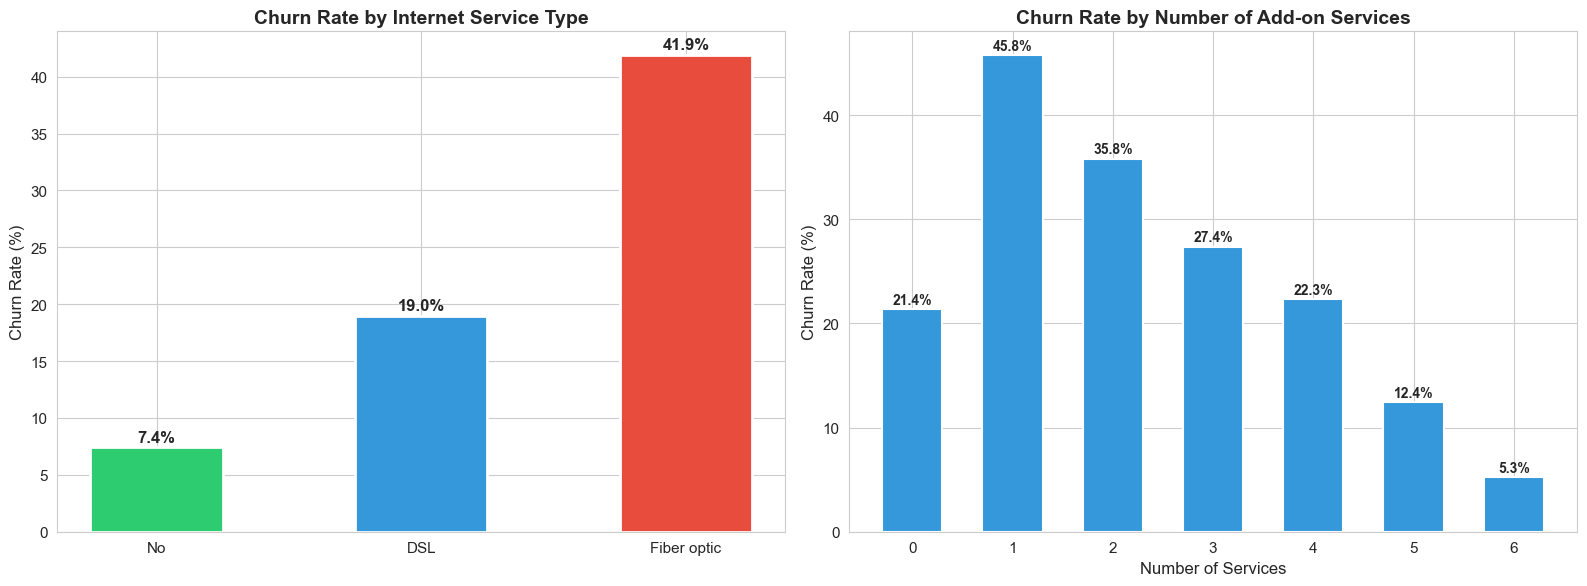

In [5]:
# 4a: Internet service type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
internet_order = ['No', 'DSL', 'Fiber optic']
internet_churn = internet_churn.reindex(internet_order)
bars = axes[0].bar(range(len(internet_churn)), internet_churn.values,
                   color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white', linewidth=2, width=0.5)
axes[0].set_xticks(range(len(internet_churn)))
axes[0].set_xticklabels(internet_churn.index)
for bar, val in zip(bars, internet_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate by Internet Service Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')

# 4b: Number of services
svc_churn = df.groupby('NumServices')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
bars = axes[1].bar(svc_churn.index, svc_churn.values, color=PALETTE[0], edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, svc_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Churn Rate by Number of Add-on Services', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Number of Services')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_services_churn.png', dpi=150, bbox_inches='tight')
plt.show()

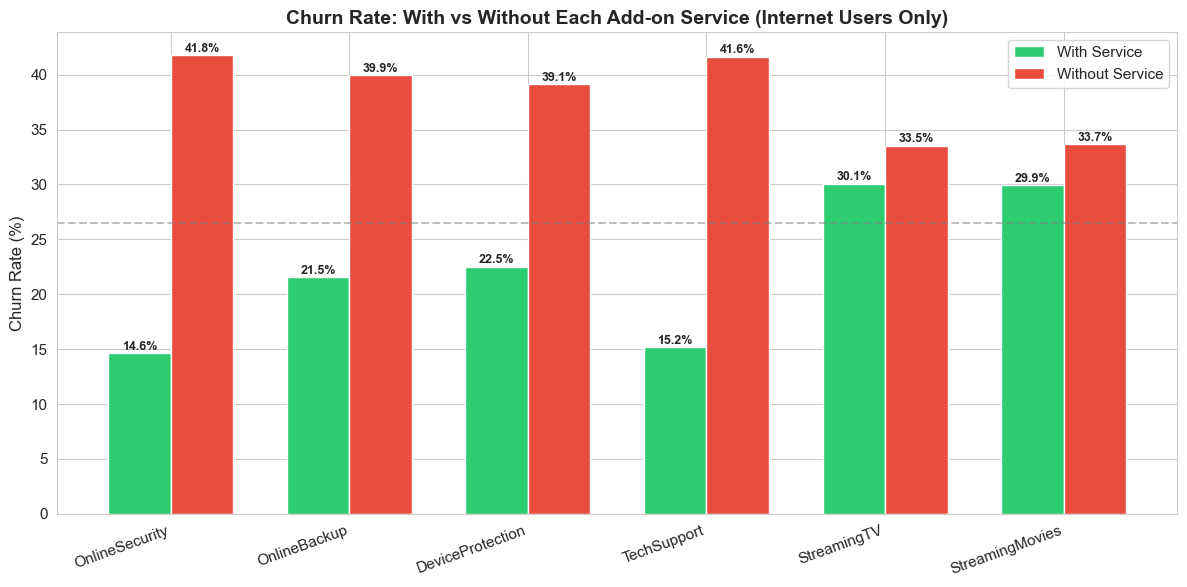

In [6]:
# 4c: Churn rate for each add-on service
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, ax = plt.subplots(figsize=(12, 6))
service_data = []
for svc in service_cols:
    internet_users = df[df['InternetService'] != 'No']
    has_svc = internet_users[internet_users[svc] == 'Yes']['Churn'].apply(lambda x: 1 if x == 'Yes' else 0).mean() * 100
    no_svc = internet_users[internet_users[svc] == 'No']['Churn'].apply(lambda x: 1 if x == 'Yes' else 0).mean() * 100
    service_data.append({'Service': svc, 'With Service': has_svc, 'Without Service': no_svc})

svc_df = pd.DataFrame(service_data)
x = np.arange(len(svc_df))
width = 0.35
bars1 = ax.bar(x - width/2, svc_df['With Service'], width, label='With Service', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, svc_df['Without Service'], width, label='Without Service', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(svc_df['Service'], rotation=20, ha='right')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate: With vs Without Each Add-on Service (Internet Users Only)', fontweight='bold')
ax.legend()
ax.axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Overall avg')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}%', 
            ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}%', 
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_service_addon_impact.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insights:**
> - **Fiber optic** customers churn at ~42%, significantly higher than DSL (~19%) and no-internet (~7%). Despite paying more, fiber customers may be experiencing service quality issues or price sensitivity.
> - **More services = lower churn.** Customers with 0 add-ons churn at ~40%+, while those with 5-6 services churn at <15%. Service bundling is a powerful retention tool.
> - **OnlineSecurity and TechSupport** are the most protective add-ons — customers with these services churn at roughly half the rate of those without.

## 5. Tenure Analysis

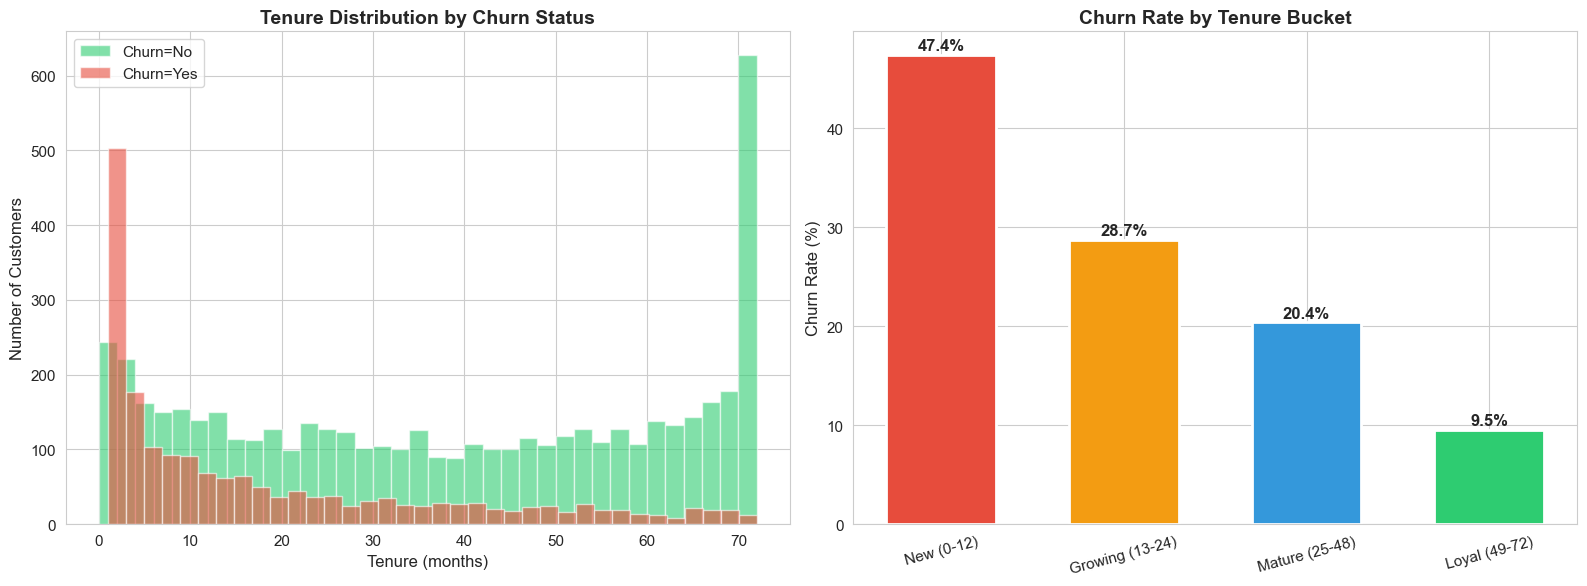

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5a: Tenure distribution by churn status
for label, color in COLORS.items():
    subset = df[df['Churn'] == label]['tenure']
    axes[0].hist(subset, bins=36, alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
axes[0].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# 5b: Churn rate by tenure bucket
bucket_order = ['New (0-12)', 'Growing (13-24)', 'Mature (25-48)', 'Loyal (49-72)']
bucket_churn = df.groupby('TenureBucket')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(bucket_order)
colors_bucket = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = axes[1].bar(range(len(bucket_churn)), bucket_churn.values, color=colors_bucket, edgecolor='white', linewidth=2, width=0.6)
axes[1].set_xticks(range(len(bucket_churn)))
axes[1].set_xticklabels(bucket_churn.index, rotation=15)
for bar, val in zip(bars, bucket_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** The first 12 months are the **"danger zone"** — new customers churn at the highest rate. Churned customers are heavily concentrated in low-tenure ranges, while retained customers show a bimodal distribution with peaks at both low and high tenure. This suggests that if a customer survives the first year, they are far more likely to stay long-term. Onboarding programs and early engagement campaigns should target this critical window.

## 6. Revenue Impact Analysis

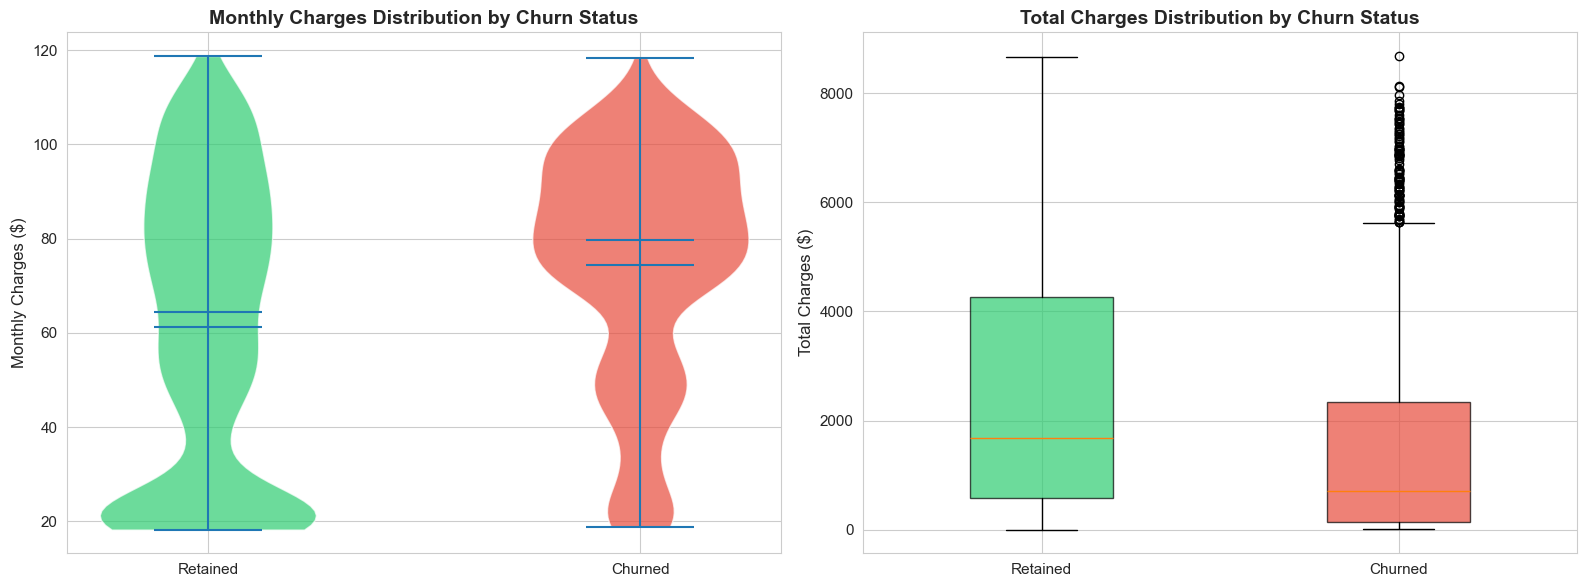

Revenue Comparison:
Metric                        Retained      Churned
--------------------------------------------------
  Avg Monthly Charges       $     61.27 $     74.44
  Median Monthly Charges    $     64.43 $     79.65
  Avg Total Charges         $  2,549.91 $  1,531.80
  Median Total Charges      $  1,679.53 $    703.55


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 6a: Monthly charges violin plot
parts = axes[0].violinplot([df[df['Churn'] == 'No']['MonthlyCharges'].values,
                            df[df['Churn'] == 'Yes']['MonthlyCharges'].values],
                           positions=[1, 2], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([COLORS['No'], COLORS['Yes']][i])
    pc.set_alpha(0.7)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_title('Monthly Charges Distribution by Churn Status', fontweight='bold')
axes[0].set_ylabel('Monthly Charges ($)')

# 6b: Total charges box plot
bp = axes[1].boxplot([df[df['Churn'] == 'No']['TotalCharges'].values,
                      df[df['Churn'] == 'Yes']['TotalCharges'].values],
                     labels=['Retained', 'Churned'], patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor(COLORS['No'])
bp['boxes'][1].set_facecolor(COLORS['Yes'])
for box in bp['boxes']:
    box.set_alpha(0.7)
axes[1].set_title('Total Charges Distribution by Churn Status', fontweight='bold')
axes[1].set_ylabel('Total Charges ($)')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Revenue stats
print("Revenue Comparison:")
print(f"{'Metric':<25} {'Retained':>12} {'Churned':>12}")
print("-" * 50)
for metric, col in [('Avg Monthly Charges', 'MonthlyCharges'), ('Median Monthly Charges', 'MonthlyCharges'),
                     ('Avg Total Charges', 'TotalCharges'), ('Median Total Charges', 'TotalCharges')]:
    func = 'mean' if 'Avg' in metric else 'median'
    ret = getattr(df[df['Churn'] == 'No'][col], func)()
    churn = getattr(df[df['Churn'] == 'Yes'][col], func)()
    print(f"  {metric:<25} ${ret:>10,.2f} ${churn:>10,.2f}")

> **Insight:** Churned customers have **higher monthly charges** on average than retained customers, indicating price sensitivity is a factor. However, churned customers have **lower total charges** because they leave earlier (low tenure). This represents a double loss: the company loses both the current revenue and the unrealized future lifetime value of these customers.

## 7. Correlation Analysis

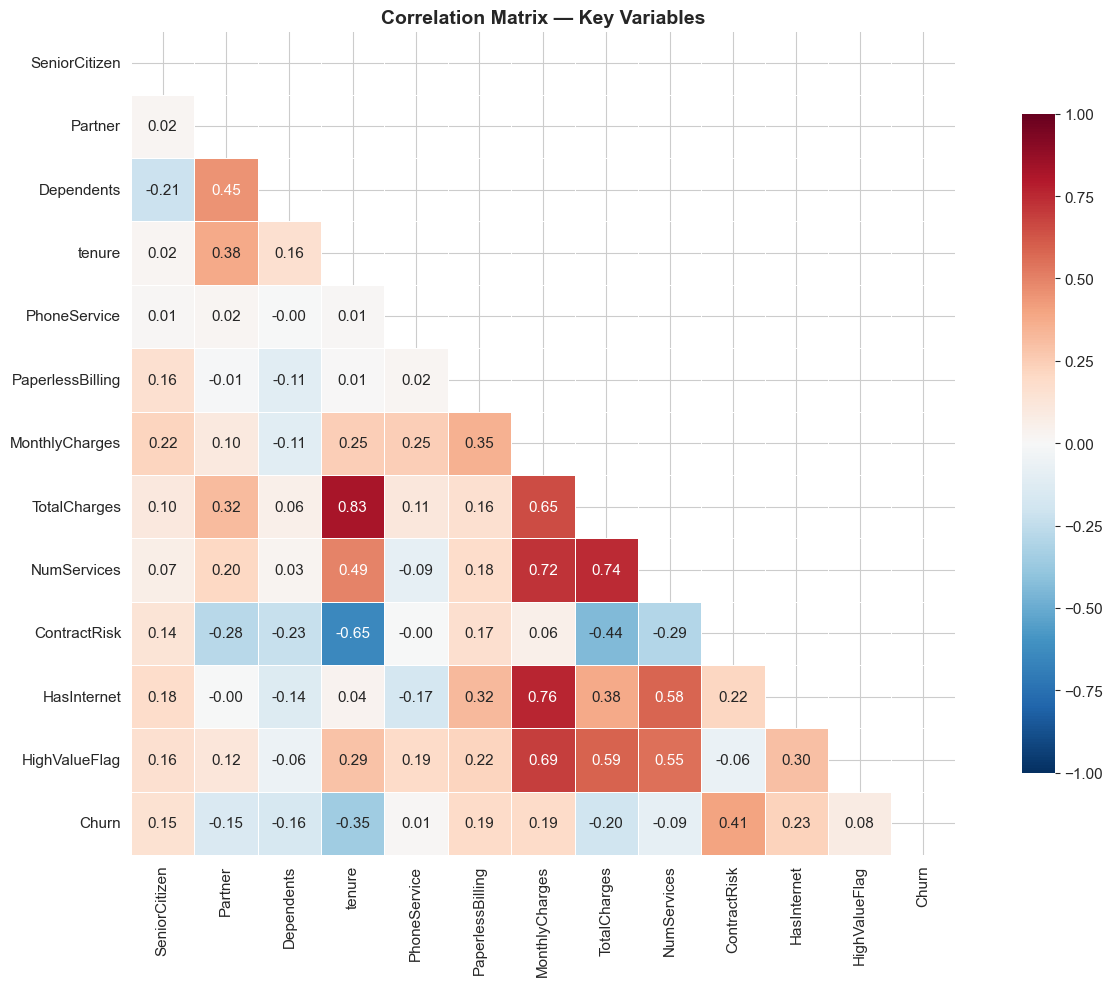

Top Correlations with Churn (absolute value):
  ContractRisk         +0.405
  tenure               -0.352
  HasInternet          +0.228
  TotalCharges         -0.198
  MonthlyCharges       +0.193
  PaperlessBilling     +0.192
  Dependents           -0.164
  SeniorCitizen        +0.151
  Partner              -0.150
  NumServices          -0.088
  HighValueFlag        +0.083
  PhoneService         +0.012


In [9]:
# Encode categorical variables for correlation
df_encoded = df.copy()
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
            'PaperlessBilling', 'Churn', 'HasInternet', 'HighValueFlag']:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(binary_map).fillna(df_encoded[col])

# Select numeric columns for correlation
corr_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
             'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'NumServices',
             'ContractRisk', 'HasInternet', 'HighValueFlag', 'Churn']
corr_df = df_encoded[corr_cols].apply(pd.to_numeric, errors='coerce')
correlation = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../tableau/screenshots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Churn
churn_corr = correlation['Churn'].drop('Churn').abs().sort_values(ascending=False)
print("Top Correlations with Churn (absolute value):")
for var, corr_val in churn_corr.items():
    direction = '+' if correlation['Churn'][var] > 0 else '-'
    print(f"  {var:<20} {direction}{corr_val:.3f}")

> **Insight:** The strongest correlations with churn are **ContractRisk** (month-to-month), **tenure** (negative — longer tenure = less churn), and **HasInternet**. Monthly charges show a moderate positive correlation, confirming price sensitivity. Partner and Dependents show negative correlation, reinforcing that household attachment aids retention.

## 8. Multi-Factor Risk Profiling

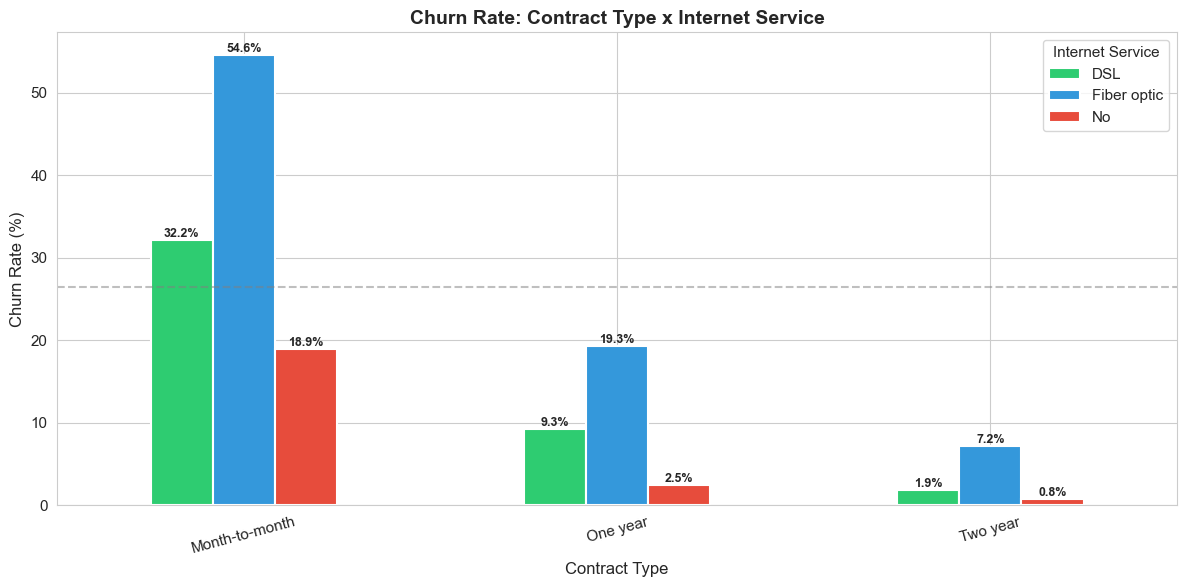

In [10]:
# Cross-tabulation: Contract x InternetService x Churn
ct = df.groupby(['Contract', 'InternetService'])['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5)
ax.set_title('Churn Rate: Contract Type x Internet Service', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(title='Internet Service')
ax.axhline(y=26.5, color='gray', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../tableau/screenshots/03_multifactor_risk.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# The "Perfect Storm" high-risk profile
high_risk = df[
    (df['Contract'] == 'Month-to-month') & 
    (df['InternetService'] == 'Fiber optic') & 
    (df['NumServices'] <= 1) & 
    (df['tenure'] <= 12)
]
high_risk_churn = (high_risk['Churn'] == 'Yes').mean() * 100
high_risk_revenue = high_risk['MonthlyCharges'].sum()

print("=" * 60)
print("HIGH-RISK PROFILE: 'The Perfect Storm'")
print("=" * 60)
print(f"Criteria: Month-to-month + Fiber optic + <=1 add-on + tenure <= 12 months")
print(f"Count:      {len(high_risk):,} customers ({len(high_risk)/len(df)*100:.1f}% of total)")
print(f"Churn Rate: {high_risk_churn:.1f}%")
print(f"Monthly Revenue at Risk: ${high_risk_revenue:,.0f}")
print(f"\nThis segment churns at {high_risk_churn/26.5:.1f}x the overall average rate.")
print("These customers should be the #1 priority for retention campaigns.")

HIGH-RISK PROFILE: 'The Perfect Storm'
Criteria: Month-to-month + Fiber optic + <=1 add-on + tenure <= 12 months
Count:      573 customers (8.1% of total)
Churn Rate: 69.3%
Monthly Revenue at Risk: $43,433

This segment churns at 2.6x the overall average rate.
These customers should be the #1 priority for retention campaigns.


## EDA Summary — Key Findings

| # | Finding | Business Impact |
|---|---|---|
| 1 | 26.5% overall churn rate, ~$139K/month revenue at risk | Significant financial exposure requiring action |
| 2 | Month-to-month contracts churn at ~42% vs ~3% for two-year | Contract upgrades are the highest-leverage retention tactic |
| 3 | Electronic check users churn at ~45% | Incentivize auto-pay enrollment |
| 4 | Fiber optic customers churn more than DSL despite higher payments | Investigate fiber service quality/pricing |
| 5 | More add-on services = dramatically lower churn | Service bundling is a key retention strategy |
| 6 | OnlineSecurity & TechSupport are most protective add-ons | Prioritize these in bundle offers |
| 7 | First 12 months are the "danger zone" for churn | Invest in onboarding & early engagement |
| 8 | Senior citizens churn at ~41% | Develop senior-specific retention programs |
| 9 | Churned customers have higher monthly but lower total charges | Price sensitivity + early departure = double revenue loss |
| 10 | "Perfect Storm" profile churns at 2-3x average rate | Target this segment for immediate intervention |

---
*Proceed to: `04_statistical_analysis.ipynb`*